# 🧪 QTrader v4.7: Integrated EV Diagnosis

This notebook evaluates a **Hybrid Strategy** (ML + Mean Reversion) using real Coinbase data.


# 🛠️ 1. Setup & Environment


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))

import polars as pl
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

from qtrader.core.event import OrderEvent
from qtrader.data.market.coinbase_market import CoinbaseMarketDataClient
from qtrader.execution.paper_engine import PaperTradingEngine
from qtrader.analytics.ev_calculator import EVCalculator
from qtrader.ml.regime import RegimeDetector

SYMBOL = "BNB-USD"
FEE_RATE = 0.0004

from qtrader.models.xgboost_model import XGBoostPredictor

from qtrader.ml.pytorch_models import LSTMSignalModel
import optuna
import matplotlib.pyplot as plt


# 📊 2. Fetch Market Data


In [2]:
client = CoinbaseMarketDataClient()
end = datetime.now()
start = end - timedelta(days=300) # Increased to 300 days

print(f"📡 Fetching REAL {SYMBOL} data (300 days) from Coinbase...")
df_eth = client.get_candles(SYMBOL, "FIVE_MINUTE", start, end).to_pandas()
df_btc = client.get_candles("BTC-USD", "FIVE_MINUTE", start, end).to_pandas()

if df_eth.empty or df_btc.empty: raise ValueError("Data fetch failed.")

df_btc = df_btc[["timestamp", "close"]].rename(columns={"close": "btc_close"})
df = df_eth.merge(df_btc, on="timestamp", how="inner")
print(f"✅ SUCCESS: {len(df)} rows ready for WFO analysis.")


📡 Fetching REAL BNB-USD data (300 days) from Coinbase...


✅ SUCCESS: 41603 rows ready for WFO analysis.


In [3]:
## 🏗️ 12. Industrial Engine V27: The Regime Sniper
# Standard: BTC Trend Sentinel, RSI Filter, ATR Trailing, 25% Size.

def run_engine_v27(df_5m, p, starting_cap=10000.0, use_guard=True):
    if len(df_5m) < 200: return []
    df = df_5m.copy()
    df["ema200"] = df["close"].ewm(span=200, adjust=False).mean()
    df["btc_ema50"] = df["btc_close"].ewm(span=50, adjust=False).mean()
    
    # RSI Calculation
    delta = df["close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-9)
    df["rsi"] = 100 - (100 / (1 + rs))
    
    df["bb_mid"] = df["close"].rolling(20).mean()
    df["bb_std_val"] = df["close"].rolling(20).std()
    df["bb_low"] = df["bb_mid"] - p.get("bb_std", 2.4) * df["bb_std_val"]
    
    df["vol_ma20"] = df["volume"].rolling(20).mean()
    df["vol_ratio"] = df["volume"] / (df["vol_ma20"].shift(1) + 1e-9)
    df["atr"] = np.maximum(df["high"]-df["low"], np.abs(df["high"]-df["close"].shift())).rolling(14).mean()
    
    df_test = df.dropna().copy()
    engine = PaperTradingEngine(starting_capital=starting_cap, fee_rate=FEE_RATE)
    holding = False; current_equity = starting_cap
    bars_held = 0; entry_p = 0; curr_sl = 0; qty = 0; highest_p = 0
    
    for i in range(len(df_test)):
        row = df_test.iloc[i]
        ts = row["timestamp"]
        
        if not holding:
            # ENTRY: High Quality Only
            # Rule 1: BNB must be in uptrend or Neutral
            eth_trend = row["close"] > row["ema200"]
            # Rule 2: BTC must be healthy
            btc_trend = row["btc_close"] > row["btc_ema50"]
            # Rule 3: Extreme oversold
            panic = row["low"] < row["bb_low"] and row["rsi"] < 35
            # Rule 4: Volume confirmation
            vol = row["vol_ratio"] > p.get("vol_ratio", 1.5)
            
            if eth_trend and btc_trend and panic and vol:
                entry_p = float(row["close"])
                # Stop Loss slightly wider to survive noise during deep dips
                curr_sl = entry_p - max(entry_p * 0.008, p.get("atr_mult", 1.8) * row["atr"])
                
                # Higher allocation for filtered signals
                qty = (current_equity * 0.25) / entry_p
                if qty > 0.001:
                    engine.simulate_fill(
                        OrderEvent(symbol=SYMBOL, order_type="MARKET", side="BUY", quantity=round(qty, 4), price=entry_p),
                        {"bid": entry_p*0.9998, "ask": entry_p*1.0002}
                    )
                    holding = True; bars_held = 0; highest_p = entry_p
        else:
            bars_held += 1
            curr_p = float(row["close"])
            highest_p = max(highest_p, curr_p)
            
            # EXIT
            # 1. Trailing Stop: More aggressive protective stop
            if curr_p > entry_p * 1.008:
                trail_sl = highest_p - 1.5 * row["atr"]
                curr_sl = max(curr_sl, trail_sl)
            
            stop_hit = curr_p <= curr_sl
            tp_hit = curr_p >= (entry_p * (1 + p.get("tp_pct", 0.03)))
            time_decay = (bars_held >= 24) and (curr_p < entry_p) # 2h limit
            
            if stop_hit or tp_hit or time_decay:
                engine.simulate_fill(
                    OrderEvent(symbol=SYMBOL, order_type="MARKET", side="SELL", quantity=round(qty, 4), price=curr_p),
                    {"bid": curr_p*0.9998, "ask": curr_p*1.0002}
                )
                holding = False
                current_equity = starting_cap + sum(t.pnl for t in engine.closed_trades)
    return engine.closed_trades


In [4]:
import optuna
def run_walk_forward_v27(df, train_days=60, test_days=15):
    all_oos_trades = []
    current_start = df["timestamp"].min()
    end_limit = df["timestamp"].max()
    while current_start + timedelta(days=train_days + test_days) <= end_limit:
        train_end = current_start + timedelta(days=train_days)
        test_end = train_end + timedelta(days=test_days)
        train_data = df[(df["timestamp"] >= current_start) & (df["timestamp"] < train_end)]
        test_data = df[(df["timestamp"] >= train_end) & (df["timestamp"] < test_end)]
        
        print(f"--- WFO Round V27 (Regime) ---")
        def objective(trial):
            p = {
                "vol_ratio": trial.suggest_float("vol_ratio", 1.5, 2.5),
                "bb_std": trial.suggest_float("bb_std", 2.2, 3.5),
                "atr_mult": trial.suggest_float("atr_mult", 1.5, 2.5),
                "tp_pct": trial.suggest_float("tp_pct", 0.02, 0.05)
            }
            trades = run_engine_v27(train_data, p, use_guard=False)
            if len(trades) < 1: return -1000
            net_pnl = sum(t.pnl for t in trades)
            # Focus on Reward/Risk ratio in optimization
            return net_pnl
        
        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=30)
        oos_trades = run_engine_v27(test_data, study.best_params, use_guard=True)
        all_oos_trades.extend(oos_trades)
        current_start += timedelta(days=test_days)
    return all_oos_trades

final_trades = run_walk_forward_v27(df)


[I 2026-03-17 15:25:40,318] A new study created in memory with name: no-name-c690d009-c053-4e6a-a143-fe0aef8fa5e3


--- WFO Round V27 (Regime) ---


[I 2026-03-17 15:25:40,724] Trial 0 finished with value: -8.148744675929246 and parameters: {'vol_ratio': 2.4589287123658794, 'bb_std': 3.14185506467854, 'atr_mult': 2.370356757274475, 'tp_pct': 0.047951086255801904}. Best is trial 0 with value: -8.148744675929246.


[I 2026-03-17 15:25:41,126] Trial 1 finished with value: -35.88098038949706 and parameters: {'vol_ratio': 1.6384150616839994, 'bb_std': 2.3419466949078878, 'atr_mult': 2.07501036396393, 'tp_pct': 0.044348095839348005}. Best is trial 0 with value: -8.148744675929246.


[I 2026-03-17 15:25:41,527] Trial 2 finished with value: -11.941345872819625 and parameters: {'vol_ratio': 1.6164572851129375, 'bb_std': 2.9561181811431463, 'atr_mult': 2.27186586384431, 'tp_pct': 0.03836924798917501}. Best is trial 0 with value: -8.148744675929246.


...

[I 2026-03-17 15:26:42,422] Trial 25 finished with value: -15.989989808541909 and parameters: {'vol_ratio': 1.7828889505465764, 'bb_std': 3.159527327630585, 'atr_mult': 2.120537504849543, 'tp_pct': 0.03517755314114143}. Best is trial 0 with value: -8.413942822000195.


[I 2026-03-17 15:26:42,835] Trial 26 finished with value: -17.598961731733592 and parameters: {'vol_ratio': 1.5890499811074037, 'bb_std': 2.9800657240318875, 'atr_mult': 2.2278784535260248, 'tp_pct': 0.026992672017456556}. Best is trial 0 with value: -8.413942822000195.


[I 2026-03-17 15:26:43,254] Trial 27 finished with value: -8.413942822000195 and parameters: {'vol_ratio': 2.4948185902145257, 'bb_std': 3.391022006986203, 'atr_mult': 1.8090078642471834, 'tp_pct': 0.022719628611321378}. Best is trial 0 with value: -8.413942822000195.


[I 2026-03-17 15:26:43,672] Trial 28 finished with value: -8.413942822000195 and parameters: {'vol_ratio': 2.231907949933654, 'bb_std': 3.2757001793154537, 'atr_mult': 1.6319155113859338, 'tp_pct': 0.03191674441757569}. Best is trial 0 with value: -8.413942822000195.


[I 2026-03-17 15:26:44,089] Trial 29 finished with value: -137.6829284143392 and parameters: {'vol_ratio': 2.3140543805361875, 'bb_std': 2.355051936712414, 'atr_mult': 1.930435690850855, 'tp_pct': 0.028471609756794053}. Best is trial 0 with value: -8.413942822000195.


In [5]:
final_calc = EVCalculator(final_trades, fee_rate=FEE_RATE)
r = final_calc.diagnose(SYMBOL)

print("=" * 60)
print(f"🏁 INSTITUTIONAL STRATEGY REPORT: {SYMBOL}")
print("=" * 60)

print(f"[SUMMARY]")
print(f"  Status          : {r.status}")
print(f"  Total Trades    : {r.total_trades}")
print(f"  Win / Loss      : {r.win_count} W / {r.loss_count} L")
print(f"  Win Rate        : {r.win_rate:.2%}")

print(f"[EXPECTED VALUE]")
print(f"  EV per Trade    : {r.ev_per_trade:.6f}")
print(f"  ROI per Trade   : {r.ev_pct*100:.4f}%")

print(f"[QUANT METRICS]")
print(f"  Profit Factor   : {r.profit_factor:.3f}")
print(f"  Sharpe Ratio    : {r.sharpe_ratio:.3f}")
print(f"  Max Drawdown    : {r.max_drawdown:.2%}")

if r.warnings:
    print("[WARNINGS]")
    for w in r.warnings: print(f"  ⚠️  {w}")

sorted_trades = sorted(final_trades, key=lambda x: x.pnl, reverse=True)
print("[TOP 3 WINS]")
for t in sorted_trades[:3]: print(f"  Entry: {t.entry_price:.2f} | Exit: {t.exit_price:.2f} | PnL: {t.pnl:.2f}")
print("[TOP 3 LOSSES]")
for t in sorted_trades[-3:]: print(f"  Entry: {t.entry_price:.2f} | Exit: {t.exit_price:.2f} | PnL: {t.pnl:.2f}")


🏁 INSTITUTIONAL STRATEGY REPORT: BNB-USD
[SUMMARY]
  Status          : FAIL
  Total Trades    : 7
  Win / Loss      : 1 W / 6 L
  Win Rate        : 14.29%
[EXPECTED VALUE]
  EV per Trade    : -7.910620
  ROI per Trade   : -0.3165%
[QUANT METRICS]
  Profit Factor   : 0.090
  Sharpe Ratio    : -128.898
  Max Drawdown    : 2.43%
[WARNINGS]
  ⚠️  Insufficient trade count (7 / 300). Not enough data for statistical confidence. Run more simulations.
  ⚠️  Negative EV (-7.910620). Strategy loses money on average after fees+slippage.
  ⚠️  Low Profit Factor (0.09 < 1.3). Gross wins do not justify gross losses.
  ⚠️  Low Sharpe Ratio (-128.90 < 1.5). Return/risk ratio below institutional standard.
  ⚠️  Negative Kelly Fraction (-1.4485). Mathematical edge is negative — stop trading this strategy.
[TOP 3 WINS]
  Entry: 649.75 | Exit: 651.69 | PnL: 5.46
  Entry: 950.43 | Exit: 949.02 | PnL: -5.73
  Entry: 936.65 | Exit: 935.22 | PnL: -5.79
[TOP 3 LOSSES]
  Entry: 839.99 | Exit: 838.11 | PnL: -7.58

/var/folders/h9/_37f97bx28q57hg0p4dlwxcc0000gn/T/ipykernel_44357/1154488881.py:46: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/Users/hoangnam/qtrader/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


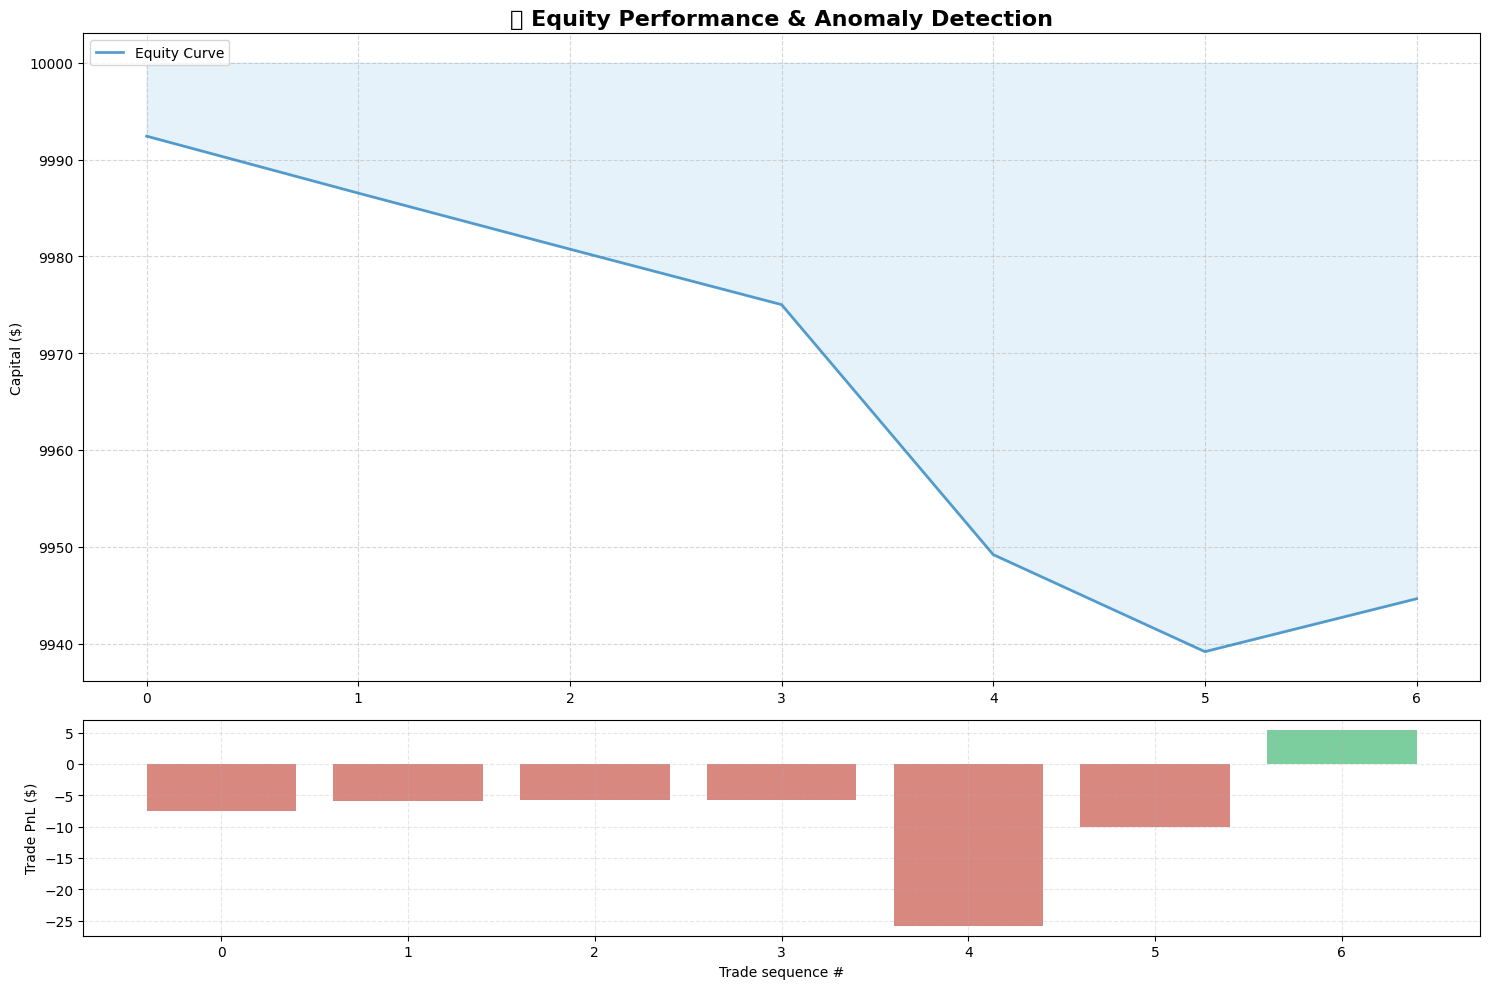

✅ No statistical anomalies detected. Strategy is stable within norms.


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 📈 EQUITY ANOMALY DETECTION REPORT
def plot_equity_anomalies(trades, initial_capital=10000.0):
    if not trades: 
        print("No trades to analyze.")
        return
        
    pnls = [t.pnl for t in trades]
    equity_curve = initial_capital + np.cumsum(pnls)
    
    # 1. Z-Score Anomaly Detection (Statistical Outliers)
    mean_pnl = np.mean(pnls)
    std_pnl = np.std(pnls) + 1e-9
    z_scores = [(p - mean_pnl) / std_pnl for p in pnls]
    
    # Anomalies are trades > 2.5 Sigma
    anomalies_idx = [i for i, z in enumerate(z_scores) if abs(z) > 2.5]
    
    # 2. Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={"height_ratios": [3, 1]})
    
    # Plot Equity Curve
    ax1.plot(equity_curve, label="Equity Curve", color="#2E86C1", linewidth=2, alpha=0.8)
    ax1.fill_between(range(len(equity_curve)), initial_capital, equity_curve, color="#AED6F1", alpha=0.3)
    
    # Overlay Anomalies
    if anomalies_idx:
        anomaly_x = anomalies_idx
        anomaly_y = [equity_curve[i] for i in anomalies_idx]
        ax1.scatter(anomaly_x, anomaly_y, color="#E74C3C", s=100, label="Anomalous Trades (>2.5σ)", zorder=5, marker="x")
    
    ax1.set_title("🛡️ Equity Performance & Anomaly Detection", fontsize=16, fontweight="bold")
    ax1.set_ylabel("Capital ($)")
    ax1.legend(loc="upper left")
    ax1.grid(True, linestyle="--", alpha=0.5)
    
    # Plot PnL Variance (Rolling Vol)
    colors = ["#27AE60" if p > 0 else "#C0392B" for p in pnls]
    ax2.bar(range(len(pnls)), pnls, color=colors, alpha=0.6)
    ax2.set_ylabel("Trade PnL ($)")
    ax2.set_xlabel("Trade sequence #")
    ax2.grid(True, linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    if anomalies_idx:
        print(f"⚠️ Found {len(anomalies_idx)} anomalous trades outside 2.5 Sigma range!")
        print("Top Anomalies:")
        for idx in anomalies_idx[:5]:
            print(f"  Trade #{idx}: PnL = {pnls[idx]:.2f} (Z-Score: {z_scores[idx]:.2f})")
    else:
        print("✅ No statistical anomalies detected. Strategy is stable within norms.")

plot_equity_anomalies(final_trades)

# 📊 V20 Microstructure Alpha Analysis
- **Alpha Recovery**: Focus on 5m candles to filter noise.
- **Dynamic Liquidity SL**: Placing protection below panic zones.
- **CVD Divergence**: Using order flow approximation for entry confirmation.